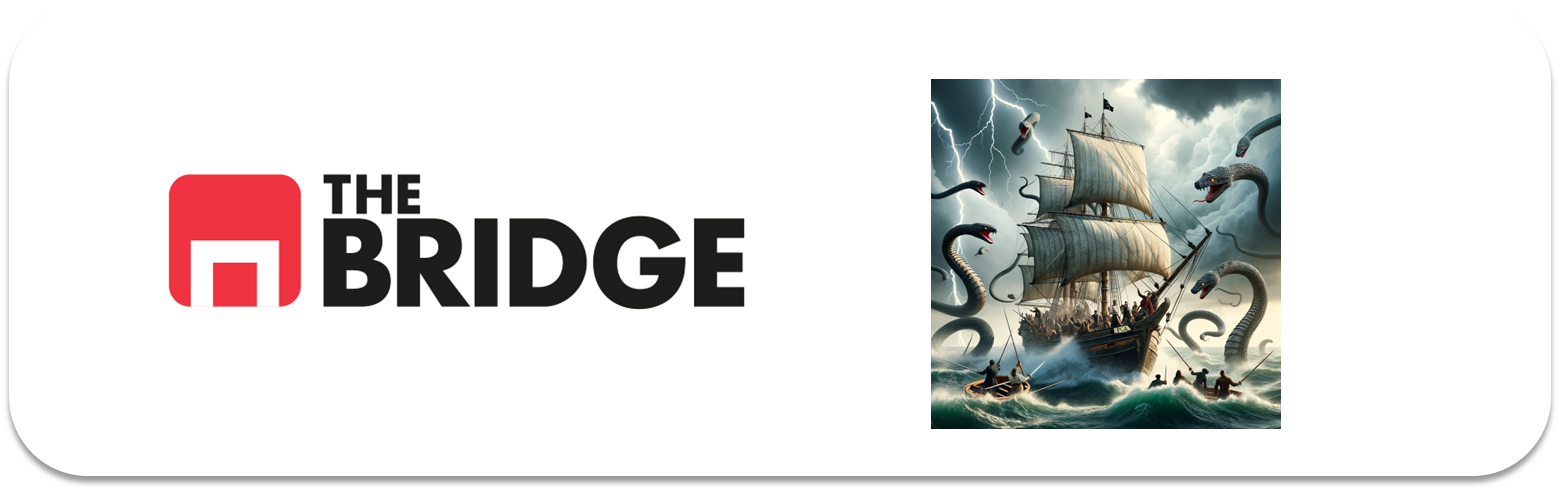

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import (SelectKBest, f_classif, mutual_info_classif,
                                       SelectFromModel, RFE, SequentialFeatureSelector)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (recall_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)
from sklearn.decomposition import PCA
from collections import Counter

RANDOM_STATE = 42 

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


## Paso 1 — Carga, limpieza y conversión a categóricas

In [21]:
df = pd.read_csv('data/credit_npo.csv')
print("Shape inicial:", df.shape)
print("\nNulos por columna:")
print(df.isnull().sum())
print("\nBalance del target (proporción):")
print(df['SeriousDlqin2yrs'].value_counts(normalize=True).round(4))

Shape inicial: (12537, 11)

Nulos por columna:
SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

Balance del target (proporción):
SeriousDlqin2yrs
0    0.9311
1    0.0689
Name: proportion, dtype: float64


In [22]:
for col in ['NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTimes90DaysLate',
            'NumberOfTime60-89DaysPastDueNotWorse']:
    print(col, '-> valores altos:')
    print(df[col].value_counts().sort_index().tail(3), '\n')

NumberOfTime30-59DaysPastDueNotWorse -> valores altos:
NumberOfTime30-59DaysPastDueNotWorse
7      1
8      2
98    21
Name: count, dtype: int64 

NumberOfTimes90DaysLate -> valores altos:
NumberOfTimes90DaysLate
10     1
13     1
98    21
Name: count, dtype: int64 

NumberOfTime60-89DaysPastDueNotWorse -> valores altos:
NumberOfTime60-89DaysPastDueNotWorse
5      4
11     1
98    21
Name: count, dtype: int64 



In [23]:
# Limpieza 
df = df.dropna().reset_index(drop=True)          # 1) fuera nulos
print("Shape sin nulos:", df.shape)

delinq = ['NumberOfTime30-59DaysPastDueNotWorse',
          'NumberOfTimes90DaysLate',
          'NumberOfTime60-89DaysPastDueNotWorse']
mask_98 = (df[delinq] == 98).any(axis=1)          # 2) detectar centinela 98
df = df[~mask_98].reset_index(drop=True)
print("Shape sin centinelas 98:", df.shape)

Shape sin nulos: (11816, 11)
Shape sin centinelas 98: (11806, 11)


In [24]:
# Conversión a categóricas 
def bin_3(serie):
    """0 / 1 / 2+  (tres niveles)"""
    return pd.cut(serie, bins=[-1, 0, 1, np.inf],
                  labels=['0', '1', '2+']).astype(str)

def bin_2(serie):
    """0 / 1+  (dos niveles: ausencia/presencia)"""
    return np.where(serie > 0, '1+', '0')

df['cat_30_59']      = bin_3(df['NumberOfTime30-59DaysPastDueNotWorse'])
df['cat_90']         = bin_2(df['NumberOfTimes90DaysLate'])
df['cat_60_89']      = bin_2(df['NumberOfTime60-89DaysPastDueNotWorse'])
df['cat_realestate'] = bin_3(df['NumberRealEstateLoansOrLines'])
df['cat_depend']     = bin_3(df['NumberOfDependents'])

# eliminamos las numéricas originales ya sustituidas
df = df.drop(columns=['NumberOfTime30-59DaysPastDueNotWorse',
                      'NumberOfTimes90DaysLate',
                      'NumberOfTime60-89DaysPastDueNotWorse',
                      'NumberRealEstateLoansOrLines',
                      'NumberOfDependents'])
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,cat_30_59,cat_90,cat_60_89,cat_realestate,cat_depend
0,0,0.081892,37,0.070709,5656.0,12,0,1+,0,0,0
1,0,0.023413,74,0.209197,4870.0,9,0,0,0,1,0
2,0,0.000000,43,0.080784,5000.0,2,0,0,0,0,2+
3,0,0.492754,44,0.412735,7333.0,4,0,0,0,2+,2+
4,0,1.000000,63,0.000000,8333.0,3,0,0,0,0,1


## Paso 2 — Codificación, split train/test y escalado

In [25]:
# One-hot de las categóricas
cat_feats = ['cat_30_59', 'cat_90', 'cat_60_89', 'cat_realestate', 'cat_depend']
num_feats = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
             'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']

df_enc = pd.get_dummies(df, columns=cat_feats, drop_first=True)
cat_enc_cols = [col for col in df_enc.columns if col.startswith('cat_')]

target = 'SeriousDlqin2yrs'
X = df_enc.drop(columns=[target])
y = df_enc[target]
all_feats = list(X.columns)
print("Nº de features tras one-hot:", len(all_feats))
print(all_feats)

Nº de features tras one-hot: 13
['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'cat_30_59_1', 'cat_30_59_2+', 'cat_90_1+', 'cat_60_89_1+', 'cat_realestate_1', 'cat_realestate_2+', 'cat_depend_1', 'cat_depend_2+']


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

# Escalado: fit SOLO en train (evita leakage)
scaler = StandardScaler().fit(X_train[num_feats])
X_train_s = X_train.copy()
X_test_s  = X_test.copy()
X_train_s[num_feats] = scaler.transform(X_train[num_feats])
X_test_s[num_feats]  = scaler.transform(X_test[num_feats])

# Objeto de validación cruzada reutilizable (estratificada)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Escalado y CV listos.")

Train: (9444, 13)  Test: (2362, 13)
Escalado y CV listos.


## Análisis visual + correlación + umbral de covarianza

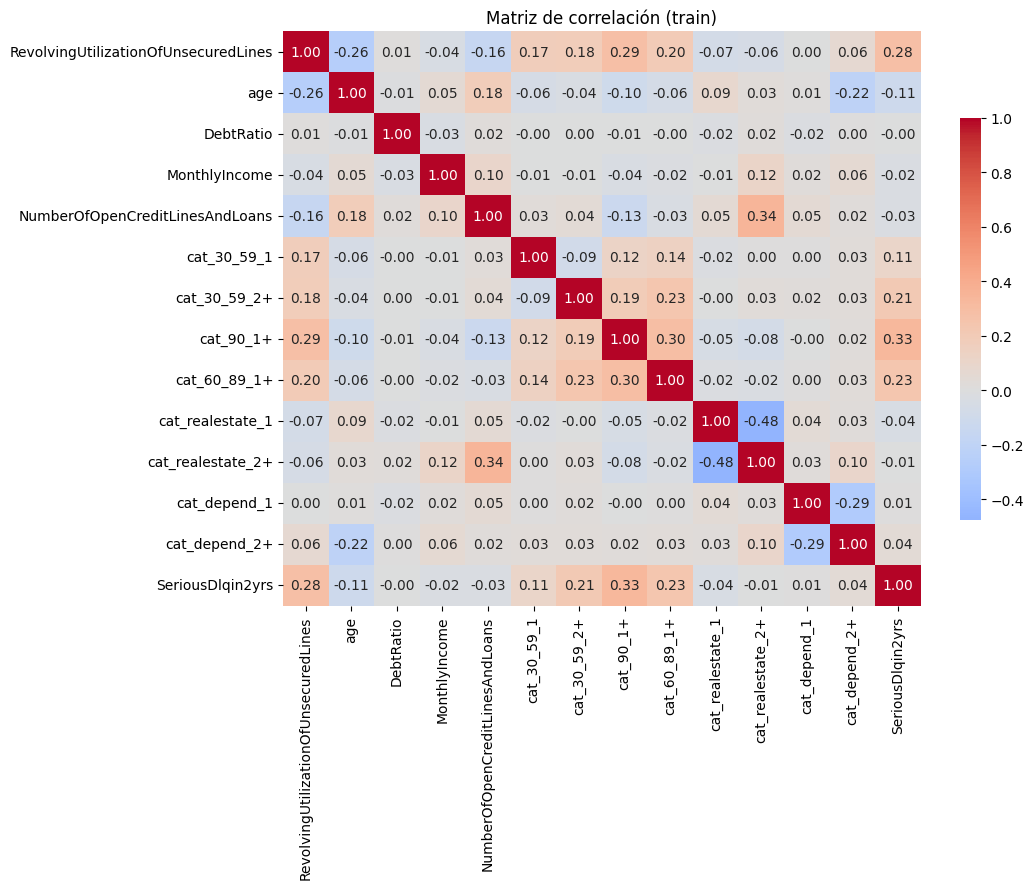

In [27]:
# Matriz de correlación (sobre train)
corr = X_train_s.join(y_train).corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'shrink': .7})
plt.title('Matriz de correlación (train)')
plt.tight_layout()
plt.show()

In [28]:
corr_target = (X_train_s.join(y_train).corr()[target]
               .drop(target).abs().sort_values(ascending=False))
print("Correlación absoluta con el target:")
print(corr_target.round(3))

lista_corr = list(corr_target.head(6).index)
print("\n[Selección 1] lista_corr:", lista_corr)

Correlación absoluta con el target:
cat_90_1+                               0.334
RevolvingUtilizationOfUnsecuredLines    0.280
cat_60_89_1+                            0.234
cat_30_59_2+                            0.214
age                                     0.109
cat_30_59_1                             0.108
cat_realestate_1                        0.041
cat_depend_2+                           0.041
NumberOfOpenCreditLinesAndLoans         0.027
MonthlyIncome                           0.022
cat_depend_1                            0.008
cat_realestate_2+                       0.006
DebtRatio                               0.003
Name: SeriousDlqin2yrs, dtype: float64

[Selección 1] lista_corr: ['cat_90_1+', 'RevolvingUtilizationOfUnsecuredLines', 'cat_60_89_1+', 'cat_30_59_2+', 'age', 'cat_30_59_1']


### Interpretación
- Las variables más correlacionadas con la morosidad son las de **retraso**
  (`cat_90_1+`, `cat_60_89_1+`, `cat_30_59_2+`) y la **utilización de crédito**
  (`RevolvingUtilization...`), lo cual tiene todo el sentido de negocio:
  *quien ya se ha retrasado y exprime su crédito es más propenso a morosidad grave*.
- Las correlaciones con el target son moderadas (ninguna enorme): es normal en scoring,
  donde la señal está repartida entre muchas variables.

## Selección 2 — `SelectKBest`+ANOVA (numéricas) y Mutual Information (categóricas)

In [29]:
skb = SelectKBest(score_func=f_classif, k=3).fit(X_train_s[num_feats], y_train)
anova_scores = pd.Series(skb.scores_, index=num_feats).sort_values(ascending=False)
num_sel = list(anova_scores.head(3).index)
print("ANOVA F-scores (numéricas):")
print(anova_scores.round(1))
print("-> seleccionadas:", num_sel)

ANOVA F-scores (numéricas):
RevolvingUtilizationOfUnsecuredLines    802.6
age                                     112.9
NumberOfOpenCreditLinesAndLoans           6.9
MonthlyIncome                             4.7
DebtRatio                                 0.1
dtype: float64
-> seleccionadas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans']


In [30]:
mi = mutual_info_classif(X_train_s[cat_enc_cols], y_train,
                         discrete_features=True, random_state=RANDOM_STATE)
mi_scores = pd.Series(mi, index=cat_enc_cols).sort_values(ascending=False)
cat_sel = list(mi_scores.head(3).index)
print("Mutual Information (categóricas):")
print(mi_scores.round(4))
print("-> seleccionadas:", cat_sel)

lista_filter = num_sel + cat_sel
print("\n[Selección 2] lista_filter:", lista_filter)

Mutual Information (categóricas):
cat_90_1+            0.0299
cat_60_89_1+         0.0160
cat_30_59_2+         0.0140
cat_30_59_1          0.0047
cat_realestate_1     0.0009
cat_depend_2+        0.0008
cat_depend_1         0.0000
cat_realestate_2+    0.0000
dtype: float64
-> seleccionadas: ['cat_90_1+', 'cat_60_89_1+', 'cat_30_59_2+']

[Selección 2] lista_filter: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'cat_90_1+', 'cat_60_89_1+', 'cat_30_59_2+']


## Selección 3 — `SelectFromModel` (modelo intermedio)

In [31]:
sfm = SelectFromModel(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                           class_weight='balanced'),
    max_features=6, threshold=-np.inf   # forzamos exactamente 6 features
).fit(X_train_s, y_train)

lista_sfm = list(np.array(all_feats)[sfm.get_support()])

# importancias del RF subyacente (para entender el porqué)
importancias = pd.Series(sfm.estimator_.feature_importances_,
                         index=all_feats).sort_values(ascending=False)
print("Importancias del RF:")
print(importancias.round(4))
print("\n[Selección 3] lista_sfm:", lista_sfm)

Importancias del RF:
RevolvingUtilizationOfUnsecuredLines    0.2703
DebtRatio                               0.1375
MonthlyIncome                           0.1317
age                                     0.1303
NumberOfOpenCreditLinesAndLoans         0.0898
cat_90_1+                               0.0801
cat_30_59_2+                            0.0467
cat_60_89_1+                            0.0392
cat_30_59_1                             0.0207
cat_depend_2+                           0.0144
cat_depend_1                            0.0141
cat_realestate_1                        0.0129
cat_realestate_2+                       0.0123
dtype: float64

[Selección 3] lista_sfm: [np.str_('RevolvingUtilizationOfUnsecuredLines'), np.str_('age'), np.str_('DebtRatio'), np.str_('MonthlyIncome'), np.str_('NumberOfOpenCreditLinesAndLoans'), np.str_('cat_90_1+')]


## Selección 4 — RFE (Recursive Feature Elimination)

In [32]:
rfe = RFE(
    estimator=LogisticRegression(max_iter=1000, class_weight='balanced',
                                 random_state=RANDOM_STATE),
    n_features_to_select=6
).fit(X_train_s, y_train)

lista_rfe = list(np.array(all_feats)[rfe.support_])
ranking = pd.Series(rfe.ranking_, index=all_feats).sort_values()
print("Ranking RFE (1 = seleccionada):")
print(ranking)
print("\n[Selección 4] lista_rfe:", lista_rfe)

Ranking RFE (1 = seleccionada):
RevolvingUtilizationOfUnsecuredLines    1
cat_30_59_1                             1
cat_30_59_2+                            1
cat_90_1+                               1
cat_60_89_1+                            1
cat_realestate_2+                       1
age                                     2
NumberOfOpenCreditLinesAndLoans         3
MonthlyIncome                           4
cat_depend_2+                           5
cat_depend_1                            6
cat_realestate_1                        7
DebtRatio                               8
dtype: int64

[Selección 4] lista_rfe: [np.str_('RevolvingUtilizationOfUnsecuredLines'), np.str_('cat_30_59_1'), np.str_('cat_30_59_2+'), np.str_('cat_90_1+'), np.str_('cat_60_89_1+'), np.str_('cat_realestate_2+')]


## Selección 5 — SFS (Sequential Feature Selection)

In [ ]:
sfs = SequentialFeatureSelector(
    estimator=LogisticRegression(max_iter=1000, class_weight='balanced',
                                 random_state=RANDOM_STATE),
    n_features_to_select=6, direction='forward',
    scoring='recall', cv=cv, n_jobs=-1
).fit(X_train_s, y_train)

lista_sfs = list(np.array(all_feats)[sfs.get_support()])
print("[Selección 5] lista_sfs:", lista_sfs)

[Selección 5] lista_sfs: [np.str_('RevolvingUtilizationOfUnsecuredLines'), np.str_('NumberOfOpenCreditLinesAndLoans'), np.str_('cat_30_59_2+'), np.str_('cat_60_89_1+'), np.str_('cat_realestate_1'), np.str_('cat_depend_2+')]


## Selección 6 — Hard-voting de las 5 técnicas anteriores

In [ ]:
votos = Counter()
for L in [lista_corr, lista_filter, lista_sfm, lista_rfe, lista_sfs]:
    votos.update(L)

conteo = pd.Series(dict(votos)).sort_values(ascending=False)
print("Votos por feature:")
print(conteo)

# nos quedamos con las que tienen >=3 votos (consenso de mayoría), máx 6
lista_voting = [f for f, n in votos.most_common() if n >= 3][:6]
if len(lista_voting) < 3:                      # red de seguridad
    lista_voting = [f for f, _ in votos.most_common(6)]
print("\n[Selección 6] lista_voting:", lista_voting)

Votos por feature:
RevolvingUtilizationOfUnsecuredLines    5
cat_90_1+                               4
cat_60_89_1+                            4
cat_30_59_2+                            4
age                                     3
NumberOfOpenCreditLinesAndLoans         3
cat_30_59_1                             2
DebtRatio                               1
MonthlyIncome                           1
cat_realestate_2+                       1
cat_realestate_1                        1
cat_depend_2+                           1
dtype: int64

[Selección 6] lista_voting: ['RevolvingUtilizationOfUnsecuredLines', 'cat_90_1+', 'cat_60_89_1+', 'cat_30_59_2+', 'age', 'NumberOfOpenCreditLinesAndLoans']


## Ejercicio 3 — Comparativa: 3 modelos × 6 listas con CV

In [ ]:
feature_sets = {
    '1_corr':   lista_corr,
    '2_filter': lista_filter,
    '3_sfm':    lista_sfm,
    '4_rfe':    lista_rfe,
    '5_sfs':    lista_sfs,
    '6_voting': lista_voting,
}

modelos = {
    'LogReg':       LogisticRegression(max_iter=1000, class_weight='balanced',
                                       random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                           random_state=RANDOM_STATE),
    'KNN':          KNeighborsClassifier(),
}

filas = []
for m_name, modelo in modelos.items():
    for f_name, feats in feature_sets.items():
        score = cross_val_score(modelo, X_train_s[feats], y_train,
                                 cv=cv, scoring='recall', n_jobs=-1).mean()
        filas.append({'modelo': m_name, 'features': f_name,
                      'n_feats': len(feats), 'recall_cv': round(score, 4)})

resultados = pd.DataFrame(filas).sort_values('recall_cv', ascending=False)
resultados.reset_index(drop=True)

,modelo,features,n_feats,recall_cv
0,LogReg,5_sfs,6,0.7598
1,LogReg,2_filter,6,0.7401
2,LogReg,6_voting,6,0.7401
3,LogReg,4_rfe,6,0.7249
4,LogReg,1_corr,6,0.7173
5,LogReg,3_sfm,6,0.7158
6,RandomForest,4_rfe,6,0.3024
7,RandomForest,5_sfs,6,0.2067
8,RandomForest,1_corr,6,0.1991
9,KNN,4_rfe,6,0.1945


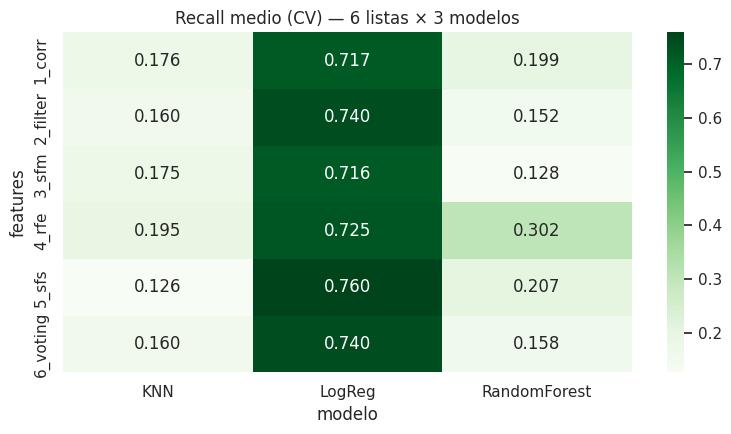

modelo,KNN,LogReg,RandomForest
features,,,
1_corr,0.1764,0.7173,0.1991
2_filter,0.1596,0.7401,0.1520
3_sfm,0.1748,0.7158,0.1277
4_rfe,0.1945,0.7249,0.3024
5_sfs,0.1261,0.7598,0.2067
6_voting,0.1596,0.7401,0.1580


In [ ]:
# Vista en tabla pivote 
pivot = resultados.pivot(index='features', columns='modelo', values='recall_cv')
plt.figure(figsize=(8, 4.5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Greens')
plt.title('Recall medio (CV) — 6 listas × 3 modelos')
plt.tight_layout()
plt.show()
pivot

In [ ]:
mejor = resultados.iloc[0]
print(f"MEJOR COMBINACIÓN -> modelo={mejor['modelo']} | "
      f"lista={mejor['features']} | recall_cv={mejor['recall_cv']}")

MEJOR COMBINACIÓN -> modelo=LogReg | lista=5_sfs | recall_cv=0.7598


## Ejercicio 4 — Optimización de hiperparámetros y evaluación contra test

In [ ]:
mejor_modelo  = mejor['modelo']
mejor_lista   = mejor['features']
feats_finales = feature_sets[mejor_lista]
print("Optimizando:", mejor_modelo, "con features", feats_finales)

if mejor_modelo == 'LogReg':
    grid = {'C': [0.01, 0.1, 1, 10, 100]}
    est  = LogisticRegression(max_iter=1000, class_weight='balanced',
                              random_state=RANDOM_STATE)
elif mejor_modelo == 'RandomForest':
    grid = {'n_estimators': [200, 400], 'max_depth': [None, 6, 10],
            'min_samples_leaf': [1, 5]}
    est  = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)
else:
    grid = {'n_neighbors': [3, 5, 7, 11]}
    est  = KNeighborsClassifier()

gs = GridSearchCV(est, grid, scoring='recall', cv=cv, n_jobs=-1)
gs.fit(X_train_s[feats_finales], y_train)
print("Mejores hiperparámetros:", gs.best_params_)
print("Recall CV (optimizado):", round(gs.best_score_, 4))

Optimizando: LogReg con features [np.str_('RevolvingUtilizationOfUnsecuredLines'), np.str_('NumberOfOpenCreditLinesAndLoans'), np.str_('cat_30_59_2+'), np.str_('cat_60_89_1+'), np.str_('cat_realestate_1'), np.str_('cat_depend_2+')]


Mejores hiperparámetros: {'C': 1}
Recall CV (optimizado): 0.7598


Recall TEST           : 0.7455
Balanced accuracy TEST: 0.7544

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.76      0.86      2197
           1       0.19      0.75      0.30       165

    accuracy                           0.76      2362
   macro avg       0.58      0.75      0.58      2362
weighted avg       0.92      0.76      0.82      2362



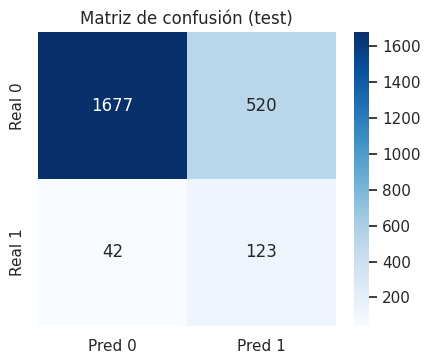

In [ ]:
# Evaluación FINAL contra test 
y_pred = gs.predict(X_test_s[feats_finales])

print("Recall TEST           :", round(recall_score(y_test, y_pred), 4))
print("Balanced accuracy TEST:", round(balanced_accuracy_score(y_test, y_pred), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 3.8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Real 0', 'Real 1'])
plt.title('Matriz de confusión (test)')
plt.tight_layout()
plt.show()

### Interpretación de resultados
- El recall en test (~0.74) es **coherente** con el de CV (~0.76): no hay sobreajuste
  apreciable; la validación cruzada predijo bien el rendimiento real.
- En la matriz de confusión vemos que capturamos la **mayoría de los morosos reales**
  (fila "Real 1"), que es el objetivo de negocio, a costa de algunos falsos positivos
  (clientes buenos marcados como riesgo). Ese intercambio es **deseable** en scoring:
  es más barato revisar de más a un cliente bueno que conceder crédito a uno que impagará.
- Conclusión: **con solo 6 variables** logramos un modelo simple, interpretable y con buen
  recall. Hemos cumplido el objetivo del enunciado: *el conjunto más sencillo con más
  potencia*.

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.